# Notebook 01: Análise Exploratória e Negócio
Este notebook é focado exclusivamente na inspeção da base crua, análise univariada e bivariada, explorando dores de negócio através de visualizações estatísticas (EDA).

## 1. Carregamento e Inspeção
Importação do dataset original e análise da volumetria e tipos de dados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
os.makedirs('../outputs/figures', exist_ok=True)

df = pd.read_csv('../data/raw/passenger_survey_balanced.csv')

print("="*40)
print("Amostra dos Dados:")
display(df.head())

print("="*40)
print("Informações e Volumetria:")
df.info()

print("="*40)
print("Estatísticas Descritivas Básicas:")
display(df.describe())


Amostra dos Dados:


,process,month,flight_type,connection,ticket_purchased_by,ticket_purchase_channel,transport_to_airport,has_disability,uses_assistive_device,requested_special_assistance,...,restrooms_is_applicable,restroom_quantity_is_applicable,restroom_cleanliness_is_applicable,restroom_maintenance_is_applicable,baggage_claim_process_is_applicable,baggage_carousel_identification_ease_is_applicable,baggage_claim_time_is_applicable,baggage_integrity_is_applicable,arrival_lead_time_is_applicable,connection_wait_time_is_applicable
0,Boarding,October,Domestic,Boarded at the airport,By the passenger,Airline website/app,Ride from someone,No,Not applicable,Not applicable,...,1,0,0,0,0,0,0,0,1,0
1,Boarding,March,Domestic,Boarded at the airport,By the passenger,Airline website/app,Ride-hailing app,No,Not applicable,Not applicable,...,1,0,0,0,0,0,0,0,1,0
2,Disembarkation,January,Domestic,Not applicable,Not applicable,Not applicable,Not applicable,No,Not applicable,Not applicable,...,0,0,0,0,1,0,0,0,0,0
3,Boarding,August,Domestic,Boarded at the airport,By the passenger,Airline website/app,Ride-hailing app,No,Not applicable,Not applicable,...,1,1,1,1,0,0,0,0,1,0
4,Boarding,February,Domestic,Boarded at the airport,By the passenger,Travel agency/third-party website,Bus,No,Not applicable,Not applicable,...,1,0,0,0,0,0,0,0,1,0


Informações e Volumetria:
<class 'pandas.DataFrame'>
RangeIndex: 57514 entries, 0 to 57513
Columns: 145 entries, process to connection_wait_time_is_applicable
dtypes: float64(62), int64(60), str(23)
memory usage: 63.6 MB
Estatísticas Descritivas Básicas:


,disembarkation_method_rating,curbside_dropoff_ease,transport_options_to_airport,checkin_process,checkin_queue_wait_time,checkin_queue_organization,self_service_kiosk_quantity,checkin_counter_quantity,staff_courtesy,checkin_service_time,...,restrooms_is_applicable,restroom_quantity_is_applicable,restroom_cleanliness_is_applicable,restroom_maintenance_is_applicable,baggage_claim_process_is_applicable,baggage_carousel_identification_ease_is_applicable,baggage_claim_time_is_applicable,baggage_integrity_is_applicable,arrival_lead_time_is_applicable,connection_wait_time_is_applicable
count,330.000000,20958.000000,16829.000000,8489.000000,1843.000000,1822.000000,340.000000,1582.000000,1587.000000,1587.000000,...,57514.000000,57514.000000,57514.000000,57514.000000,57514.000000,57514.000000,57514.000000,57514.000000,57514.000000,57514.000000
mean,3.739394,4.131215,3.807832,4.075745,2.670646,2.875412,3.220588,2.665613,3.615627,3.293636,...,0.578694,0.131133,0.131133,0.131133,0.421306,0.085910,0.085910,0.085910,0.387871,0.190823
std,1.171583,0.953496,1.055072,1.122362,1.305023,1.276820,1.142445,1.239787,1.196762,1.251271,...,0.493773,0.337549,0.337549,0.337549,0.493773,0.280233,0.280233,0.280233,0.487269,0.392953
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,4.000000,3.000000,4.000000,1.500000,2.000000,2.000000,2.000000,3.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,4.000000,4.000000,4.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.000000,5.000000,5.000000,5.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 2. Análise Univariada (A Dor)
Distribuição da nossa variável alvo (`liked`).

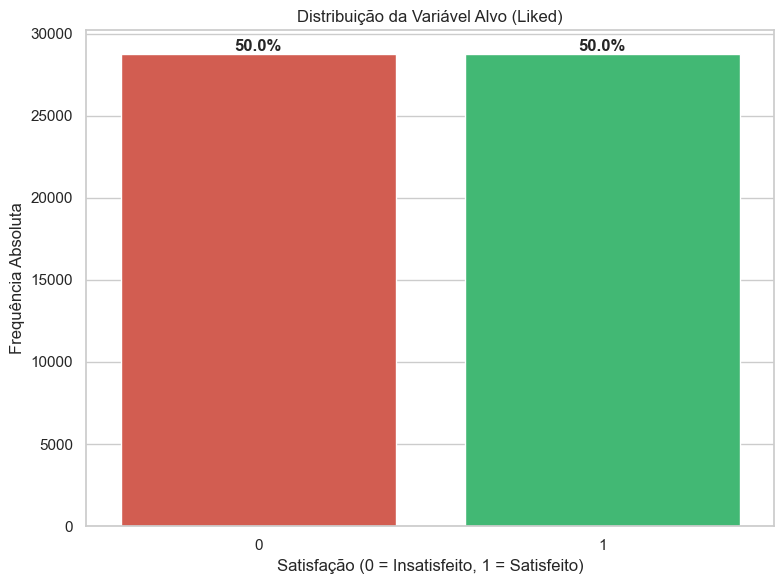

In [2]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='liked', hue='liked', palette={0: '#e74c3c', 1: '#2ecc71'}, legend=False)
plt.title('Distribuição da Variável Alvo (Liked)')
plt.xlabel('Satisfação (0 = Insatisfeito, 1 = Satisfeito)')
plt.ylabel('Frequência Absoluta')

# Adicionando rótulos percentuais
total_samples = len(df)
for p in ax.patches:
    height = p.get_height()
    perc = f'{height / total_samples:.1%}'
    ax.annotate(perc, (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/distribuicao_alvo.png', dpi=300)
plt.show()


## 3. Análise Bivariada (As Hipóteses)
Cruzamentos para explorar a relação entre características da viagem (ex: tipo de voo, classe) e a satisfação do passageiro.

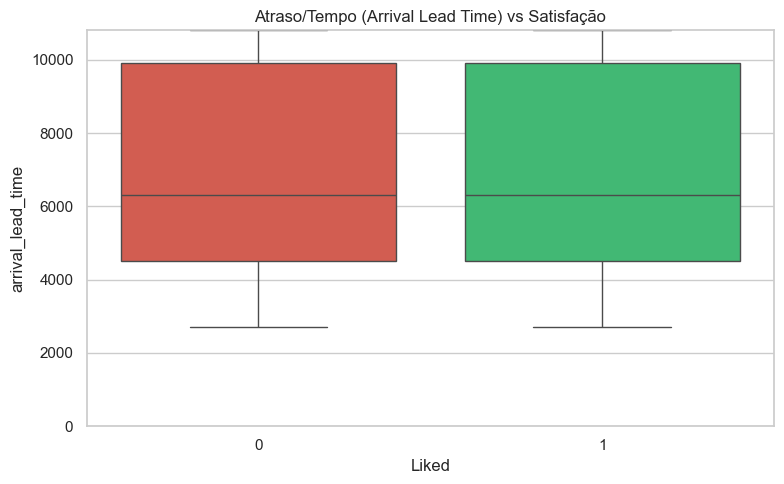

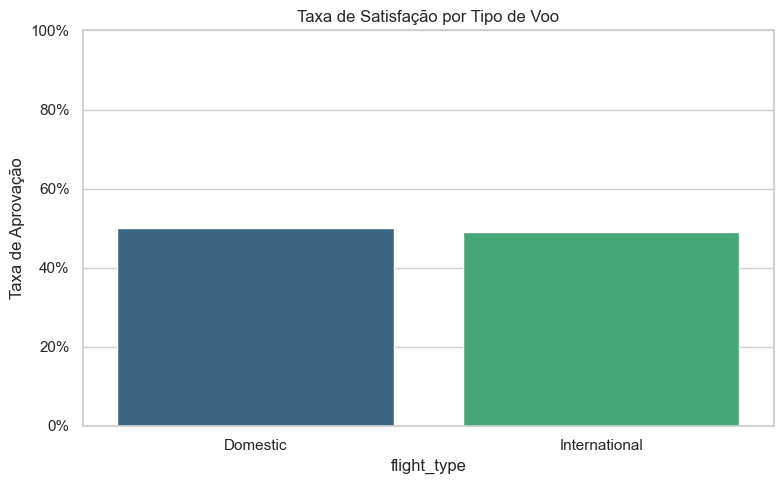

In [3]:
# Exemplo 1: Classe do cliente vs Satisfação
if 'customer_class' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.barplot(data=df, x='customer_class', y='liked', hue='customer_class', errorbar=None, palette='Blues', legend=False)
    plt.title('Taxa de Satisfação Média por Classe do Passageiro')
    plt.ylabel('Taxa de Aprovação')
    plt.ylim(0, 1)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    plt.tight_layout()
    plt.savefig('../outputs/figures/satisfacao_por_classe.png', dpi=300)
    plt.show()

# Exemplo 2: Atraso vs Satisfação
if 'arrival_lead_time' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='liked', y='arrival_lead_time', hue='liked', palette={0: '#e74c3c', 1: '#2ecc71'}, legend=False)
    plt.title('Atraso/Tempo (Arrival Lead Time) vs Satisfação')
    plt.xlabel('Liked')
    plt.ylim(0, df['arrival_lead_time'].quantile(0.95)) # Focando no grosso da distribuição
    plt.tight_layout()
    plt.savefig('../outputs/figures/atrasos_vs_satisfacao.png', dpi=300)
    plt.show()

# Exemplo 3: Tipo de Voo
if 'flight_type' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.barplot(data=df, x='flight_type', y='liked', hue='flight_type', errorbar=None, palette='viridis', legend=False)
    plt.title('Taxa de Satisfação por Tipo de Voo')
    plt.ylabel('Taxa de Aprovação')
    plt.ylim(0, 1)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    plt.tight_layout()
    plt.savefig('../outputs/figures/satisfacao_por_tipo_voo.png', dpi=300)
    plt.show()


## 4. Mapa de Calor (Correlação)
Identificando quais variáveis numéricas possuem maior peso e andam juntas com a satisfação.

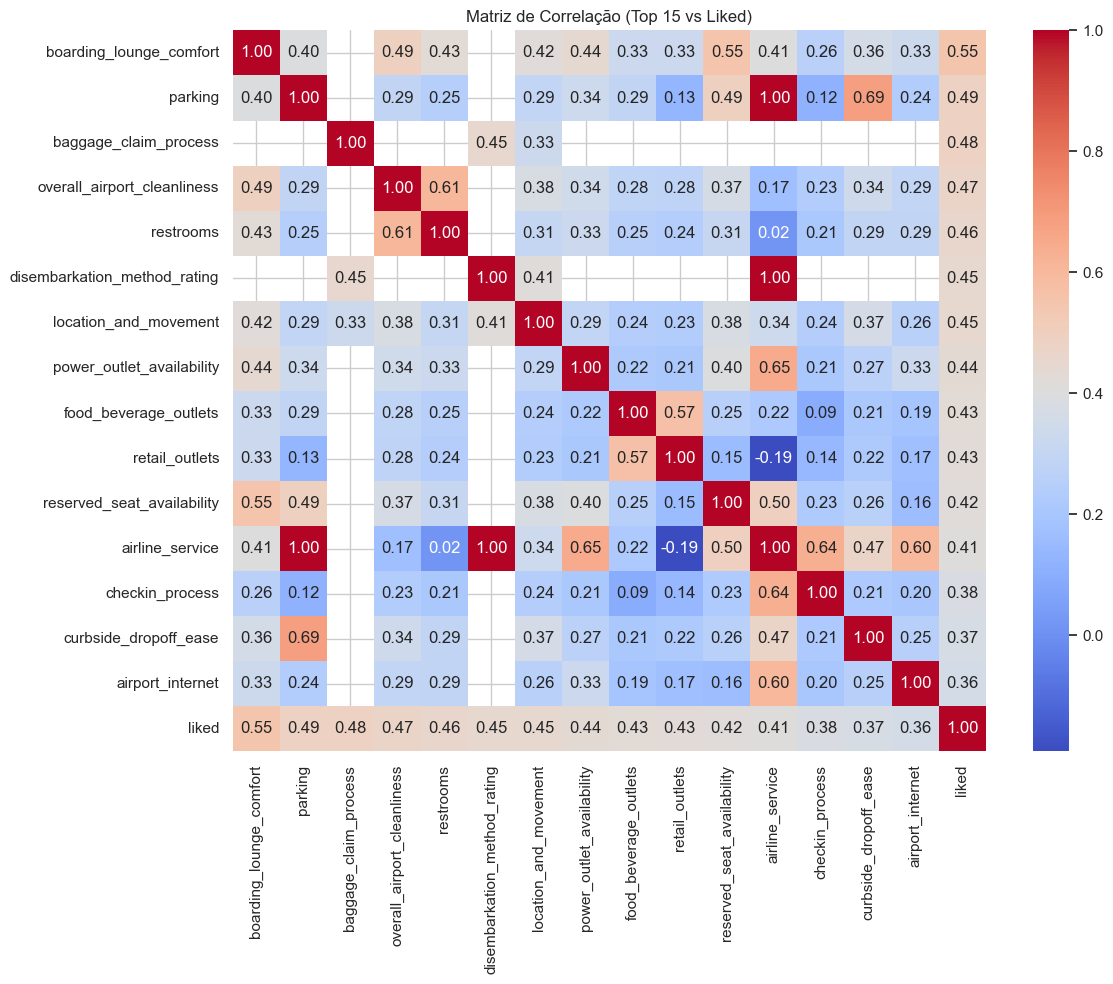

In [4]:
# Filtrar colunas numéricas que não são as flags _is_applicable
num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and not str(c).endswith('_is_applicable') and c != 'liked']

# Pegar as 15 variáveis mais correlacionadas com a satisfação
corr_with_liked = df[num_cols].corrwith(df['liked']).abs().sort_values(ascending=False).head(15)
top_cols = corr_with_liked.index.tolist()

plt.figure(figsize=(12, 10))
sns.heatmap(df[top_cols + ['liked']].corr(), annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Matriz de Correlação (Top 15 vs Liked)')
plt.tight_layout()
plt.savefig('../outputs/figures/heatmap_correlacao.png', dpi=300)
plt.show()
